# Linear Regression

## What is Linear Regression?
Linear Regression is one of the oldest and most widely used algorithms in statistics and machine learning. It models the **linear relationship** between a dependent variable $y$ and one or more independent variables $x$.

- **Simple Linear Regression**: One input feature
- **Multiple Linear Regression**: Multiple input features

**History**: First developed by Francis Galton in 1886 to study the relationship between parents' and children's heights. The method was later formalized by Karl Pearson.

---

## 1. Simple Linear Regression

The hypothesis function:

$$h_\theta(x) = \theta_0 + \theta_1 x$$

Where:
- $\theta_0$ = intercept (bias)
- $\theta_1$ = slope (weight)

---

## 2. Multiple Linear Regression

$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n = \theta^T x$$

In matrix form: $\hat{y} = X\theta$

---

## 3. Cost Function (Mean Squared Error)

We want to find $\theta$ that minimizes the cost:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

- $m$ = number of training examples
- The $\frac{1}{2}$ is for mathematical convenience (cancels with the 2 from the derivative)

---

## 4. Gradient Descent

Update rule for each parameter simultaneously:

$$\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}$$

The partial derivative:

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}$$

In matrix form:

$$\nabla_\theta J = \frac{1}{m} X^T (X\theta - y)$$

$$\theta := \theta - \frac{\alpha}{m} X^T (X\theta - y)$$

---

## 5. Normal Equation (Closed-Form Solution)

Instead of iterating, solve directly:

$$\theta = (X^T X)^{-1} X^T y$$

**Derivation**: Set $\nabla_\theta J = 0$:
$$X^T X \theta = X^T y \Rightarrow \theta = (X^T X)^{-1} X^T y$$

**When to use**:
- Normal equation: small datasets (n features < 10,000), exact solution
- Gradient descent: large datasets, more scalable

---

## 6. Assumptions of Linear Regression (LINE)

1. **L**inearity: relationship between X and y is linear
2. **I**ndependence: observations are independent
3. **N**ormality: residuals are normally distributed
4. **E**qual variance (Homoscedasticity): residuals have constant variance

Additional: No multicollinearity among features

---

## 7. Regularization

### Ridge Regression (L2)
Adds squared magnitude of coefficients:

$$J(\theta) = MSE + \alpha \sum_{j=1}^{n} \theta_j^2$$

Closed form: $\theta = (X^T X + \alpha I)^{-1} X^T y$

### Lasso Regression (L1)
Adds absolute magnitude produces sparse solutions:

$$J(\theta) = MSE + \alpha \sum_{j=1}^{n} |\theta_j|$$

### ElasticNet
Combination of L1 and L2:

$$J(\theta) = MSE + \alpha \rho \sum|\theta_j| + \frac{\alpha(1-\rho)}{2} \sum \theta_j^2$$

---

## 8. Evaluation Metrics

$$MAE = \frac{1}{m}\sum_{i=1}^{m}|y_i - \hat{y}_i|$$

$$MSE = \frac{1}{m}\sum_{i=1}^{m}(y_i - \hat{y}_i)^2$$

$$RMSE = \sqrt{MSE}$$

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

$$R^2_{adj} = 1 - (1-R^2)\frac{m-1}{m-n-1}$$

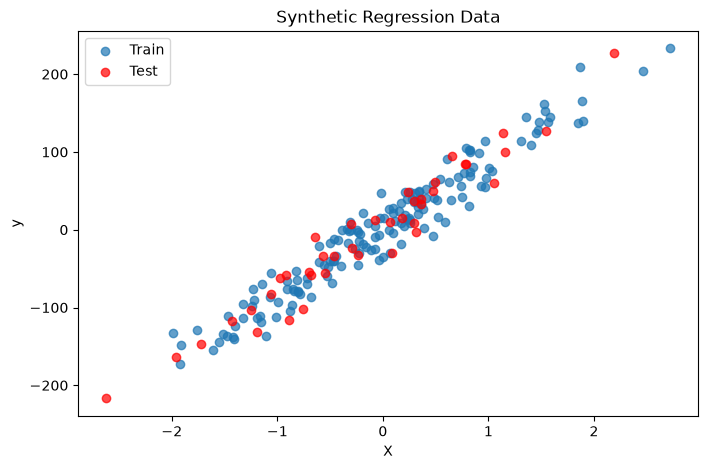

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Generate synthetic data
X, y = make_regression(n_samples=200, n_features=1, noise=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.7, label='Train')
plt.scatter(X_test, y_test, alpha=0.7, color='red', label='Test')
plt.xlabel('X'); plt.ylabel('y'); plt.title('Synthetic Regression Data'); plt.legend()
plt.show()

## Implementation from Scratch

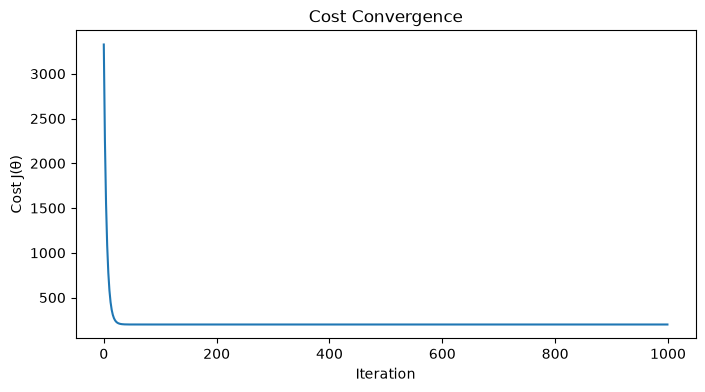

GD theta:  [ 1.69178356 79.06737525]
NE theta:  [ 1.69178356 79.06737525]


In [2]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.theta = None
        self.cost_history = []

    def _add_bias(self, X):
        return np.c_[np.ones(X.shape[0]), X]

    def fit(self, X, y):
        X_b = self._add_bias(X)
        m, n = X_b.shape
        self.theta = np.zeros(n)

        for _ in range(self.n_iter):
            predictions = X_b @ self.theta
            errors = predictions - y
            cost = (1 / (2 * m)) * np.sum(errors ** 2)
            self.cost_history.append(cost)
            gradient = (1 / m) * X_b.T @ errors
            self.theta -= self.lr * gradient
        return self

    def predict(self, X):
        return self._add_bias(X) @ self.theta

    def normal_equation(self, X, y):
        """Closed-form: theta = (X^T X)^{-1} X^T y"""
        X_b = self._add_bias(X)
        self.theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
        return self


# Gradient Descent
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_gd = LinearRegressionScratch(learning_rate=0.1, n_iterations=1000)
model_gd.fit(X_train_scaled, y_train)

plt.figure(figsize=(8, 4))
plt.plot(model_gd.cost_history)
plt.xlabel('Iteration'); plt.ylabel('Cost J(θ)'); plt.title('Cost Convergence')
plt.show()

# Normal Equation
model_ne = LinearRegressionScratch()
model_ne.normal_equation(X_train_scaled, y_train)

print(f'GD theta:  {model_gd.theta}')
print(f'NE theta:  {model_ne.theta}')

## Gradient Descent Variants: Batch vs SGD vs Mini-batch

Three variants of gradient descent differ in how much data they use per update:

- **Batch GD**: uses all training samples per update. Smooth convergence, but slow and memory-intensive on large datasets.
- **SGD (Stochastic)**: updates on one sample at a time. Fast and memory-efficient, but the loss curve is noisy and convergence can oscillate.
- **Mini-batch GD**: updates on a small batch (commonly 32-256 samples). Balances the smoothness of batch GD with the speed of SGD. This is the standard approach in deep learning.


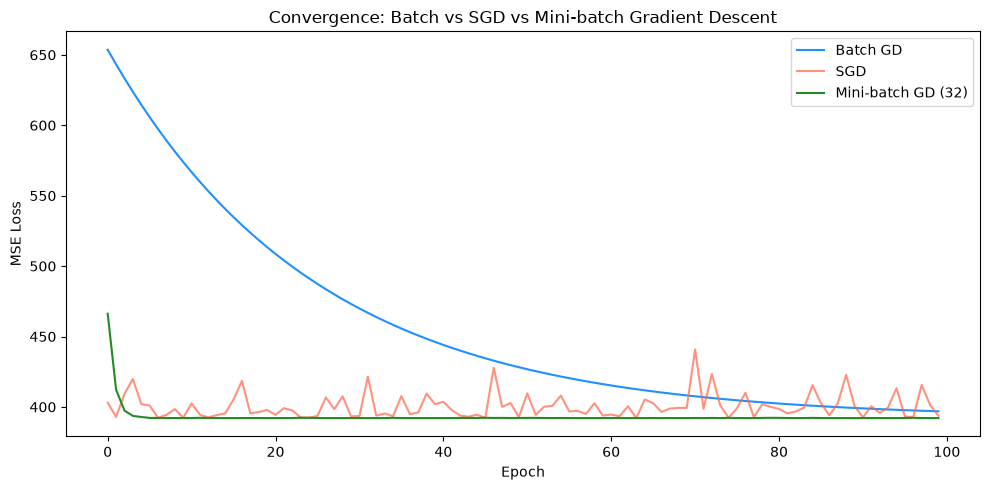

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X_gd, y_gd = make_regression(n_samples=1000, n_features=1, noise=20, random_state=42)
X_gd = (X_gd - X_gd.mean()) / X_gd.std()

def batch_gd(X, y, lr=0.01, epochs=100):
    w, b = 0.0, 0.0
    losses = []
    for _ in range(epochs):
        pred = X[:,0]*w + b
        loss = ((pred - y)**2).mean()
        losses.append(loss)
        w -= lr * (2*(pred - y)*X[:,0]).mean()
        b -= lr * (2*(pred - y)).mean()
    return losses

def sgd(X, y, lr=0.01, epochs=100):
    w, b = 0.0, 0.0
    losses = []
    idx = np.arange(len(y))
    for _ in range(epochs):
        np.random.shuffle(idx)
        for i in idx:
            pred = X[i,0]*w + b
            loss = (pred - y[i])**2
            w -= lr * 2*(pred - y[i])*X[i,0]
            b -= lr * 2*(pred - y[i])
        losses.append(((X[:,0]*w + b - y)**2).mean())
    return losses

def minibatch_gd(X, y, lr=0.01, epochs=100, batch_size=32):
    w, b = 0.0, 0.0
    losses = []
    for _ in range(epochs):
        idx = np.random.permutation(len(y))
        for start in range(0, len(y), batch_size):
            batch = idx[start:start+batch_size]
            pred = X[batch,0]*w + b
            w -= lr * (2*(pred - y[batch])*X[batch,0]).mean()
            b -= lr * (2*(pred - y[batch])).mean()
        losses.append(((X[:,0]*w + b - y)**2).mean())
    return losses

batch_losses = batch_gd(X_gd, y_gd)
sgd_losses = sgd(X_gd, y_gd)
mb_losses = minibatch_gd(X_gd, y_gd)

plt.figure(figsize=(10,5))
plt.plot(batch_losses, label='Batch GD', color='dodgerblue')
plt.plot(sgd_losses, label='SGD', color='tomato', alpha=0.7)
plt.plot(mb_losses, label='Mini-batch GD (32)', color='forestgreen')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Convergence: Batch vs SGD vs Mini-batch Gradient Descent')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation Metrics from Scratch

In [4]:
def mae(y_true, y_pred): return np.mean(np.abs(y_true - y_pred))
def mse(y_true, y_pred): return np.mean((y_true - y_pred) ** 2)
def rmse(y_true, y_pred): return np.sqrt(mse(y_true, y_pred))
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

y_pred = model_gd.predict(X_test_scaled)
print(f'MAE:  {mae(y_test, y_pred):.4f}')
print(f'MSE:  {mse(y_test, y_pred):.4f}')
print(f'RMSE: {rmse(y_test, y_pred):.4f}')
print(f'R²:   {r2(y_test, y_pred):.4f}')

MAE:  16.0405
MSE:  437.5499
RMSE: 20.9177
R²:   0.9450


## Residual Analysis

Residual analysis checks whether the LINE assumptions hold after fitting a model:

- **Residuals vs Fitted**: plots residuals against predicted values. A random scatter around zero confirms linearity and homoscedasticity (equal variance). Patterns or funnels signal violations.
- **Q-Q Plot**: compares residual quantiles to a normal distribution. Points falling on the diagonal line confirm the normality of residuals assumption.
- **Residual Distribution**: a histogram of residuals should be roughly bell-shaped and centered at zero.

Both the residuals-vs-fitted and Q-Q plot directly test the L (Linearity) and N (Normality) parts of the LINE assumptions.


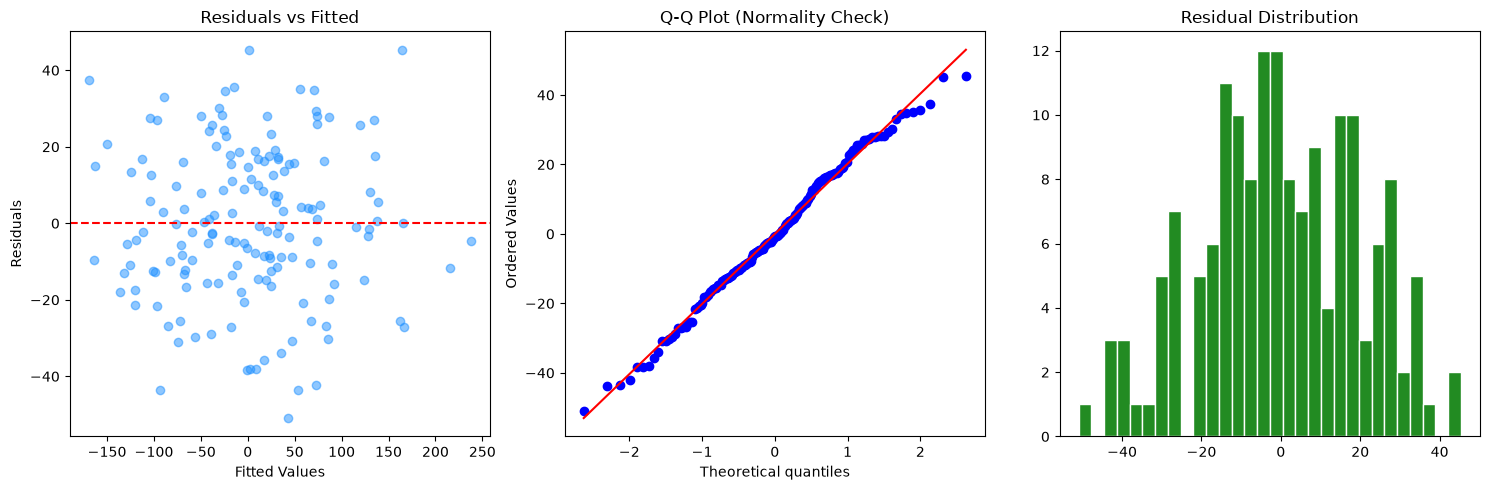

In [5]:
from sklearn.linear_model import LinearRegression
import scipy.stats as stats

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_train = lr_model.predict(X_train)
residuals = y_train - y_pred_train

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(y_pred_train, residuals, alpha=0.5, color='dodgerblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)')

axes[2].hist(residuals, bins=30, color='forestgreen', edgecolor='white')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

## Polynomial Regression

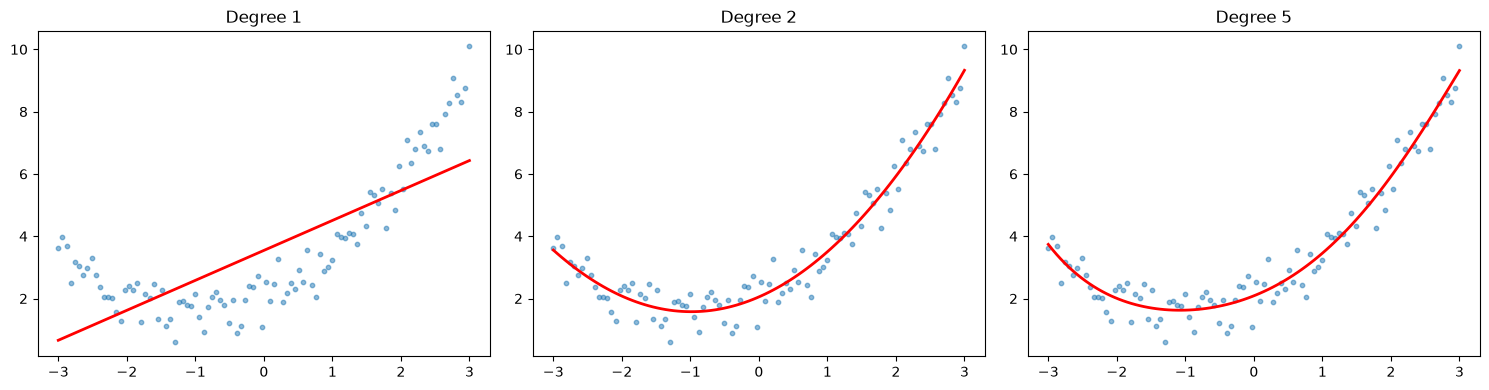

In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Create non-linear data
X_nl = np.linspace(-3, 3, 100).reshape(-1, 1)
y_nl = 0.5 * X_nl**2 + X_nl + 2 + np.random.randn(100, 1) * 0.5

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, degree in enumerate([1, 2, 5]):
    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])
    poly_model.fit(X_nl, y_nl)
    y_plot = poly_model.predict(X_nl)
    axes[i].scatter(X_nl, y_nl, s=10, alpha=0.5)
    axes[i].plot(X_nl, y_plot, color='red', linewidth=2)
    axes[i].set_title(f'Degree {degree}')
plt.tight_layout(); plt.show()

## Ridge, Lasso, ElasticNet with Scikit-Learn

In [7]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.datasets import load_diabetes

X_d, y_d = load_diabetes(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

models = {
    'Linear': LinearRegression(),
    'Ridge (α=1)': Ridge(alpha=1.0),
    'Lasso (α=0.1)': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5)
}

for name, model in models.items():
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    print(f'{name:20s} | R²: {r2(y_te, preds):.4f} | RMSE: {rmse(y_te, preds):.2f}')

Linear               | R²: 0.4526 | RMSE: 53.85
Ridge (α=1)          | R²: 0.4192 | RMSE: 55.47
Lasso (α=0.1)        | R²: 0.4719 | RMSE: 52.90
ElasticNet           | R²: 0.0987 | RMSE: 69.10


## Multicollinearity & VIF

In [8]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_df = pd.DataFrame(X_d, columns=[f'f{i}' for i in range(X_d.shape[1])])
vif_data = pd.DataFrame()
vif_data['Feature'] = X_df.columns
vif_data['VIF'] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
print(vif_data)
# VIF > 10 indicates high multicollinearity

  Feature        VIF
0      f0   1.217307
1      f1   1.278071
2      f2   1.509437
3      f3   1.459428
4      f4  59.202510
5      f5  39.193370
6      f6  15.402156
7      f7   8.890986
8      f8  10.075967
9      f9   1.484623


## Learning Curve

A learning curve plots training and validation scores against training set size. It helps diagnose:

- **High bias (underfitting)**: both curves plateau at a low score regardless of more data.
- **High variance (overfitting)**: large gap between training and validation scores that closes as more data is added.

For Ridge regression, the regularization term controls the bias-variance tradeoff, so the gap should be small.


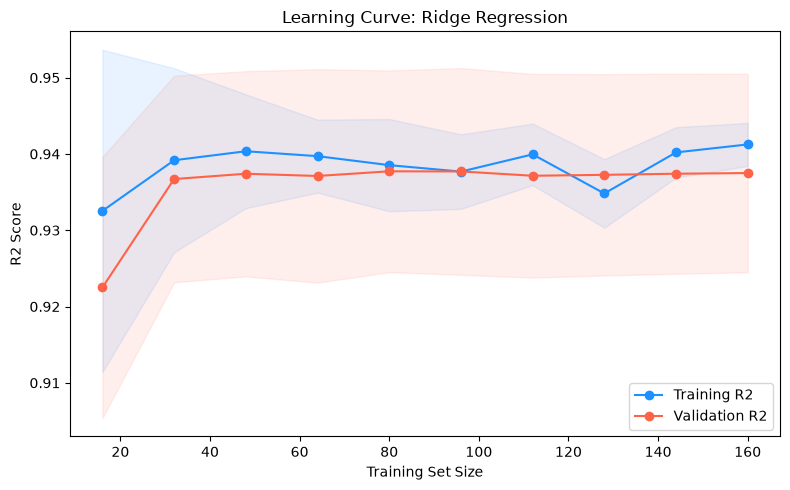

In [9]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Ridge

train_sizes, train_scores, val_scores = learning_curve(
    Ridge(alpha=1.0), X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2')

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='dodgerblue', label='Training R2')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='tomato', label='Validation R2')
plt.fill_between(train_sizes,
                 train_scores.mean(1)-train_scores.std(1),
                 train_scores.mean(1)+train_scores.std(1),
                 alpha=0.1, color='dodgerblue')
plt.fill_between(train_sizes,
                 val_scores.mean(1)-val_scores.std(1),
                 val_scores.mean(1)+val_scores.std(1),
                 alpha=0.1, color='tomato')
plt.xlabel('Training Set Size')
plt.ylabel('R2 Score')
plt.title('Learning Curve: Ridge Regression')
plt.legend()
plt.tight_layout()
plt.show()

## Additional Learning Resources

### Papers & Books
- 📄 [The Elements of Statistical Learning (ESL)](https://web.stanford.edu/~hastie/ElemStatLearn/) Hastie, Tibshirani, Friedman Chapter 3
- 📄 [An Introduction to Statistical Learning (ISLR)](https://www.statlearning.com/) Free PDF Chapter 3
- 📖 [Pattern Recognition and Machine Learning](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf) Bishop Chapter 3

### Courses & Videos
- 🎥 [Andrew Ng CS229 Lecture Notes](https://cs229.stanford.edu/lectures-spring2022/main_notes.pdf) Linear Regression notes
- 🎥 [StatQuest: Linear Regression](https://www.youtube.com/watch?v=nk2CQITm_eo) Josh Starmer
- 🎥 [3Blue1Brown: Linear Algebra](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab)

### Documentation
- 📚 [Scikit-Learn Linear Models](https://scikit-learn.org/stable/modules/linear_model.html)
- 📚 [Statsmodels OLS](https://www.statsmodels.org/stable/regression.html)

### Interactive
- 🌐 [Kaggle: Intro to Machine Learning](https://www.kaggle.com/learn/intro-to-machine-learning)
- 🌐 [Google ML Crash Course: Linear Regression](https://developers.google.com/machine-learning/crash-course/linear-regression)